# Beskrivning
Tränar en linjär regressions modell eller en RandomForest modell på data från de 100 mest populära hamnarna i datasetet. Försöker predikera antalet båtar närvarande.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statistics import mean, stdev
from google.colab import drive

In [ ]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/boats_at_harbor/boats_at_harbor.csv")

# Data preparation

In [ ]:
df['datum'] = pd.to_datetime(df['datum'], utc=True)

df["windDirectionDegrees"] = pd.to_numeric(df["windDirectionDegrees"], errors="coerce")
df["windSpeedMps"] = pd.to_numeric(df["windSpeedMps"], errors="coerce")
df["temperatureCelsius"] = pd.to_numeric(df["temperatureCelsius"], errors="coerce")
df["boats_at_harbor"] = pd.to_numeric(df["boats_at_harbor"], errors="coerce")
df["day_of_week"] = pd.to_numeric(df["day_of_week"], errors="coerce")
df["precipitationMm"] = pd.to_numeric(df["precipitationMm"], errors="coerce")

# Feature engineering

Hour cos and sin

In [ ]:
df['hour'] = df['datum'].dt.hour
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

Wind cos and sin

In [ ]:
wind_rad = np.deg2rad(df['windDirectionDegrees'])
df["wind_dir_sin"] = np.sin(wind_rad)
df["wind_dir_cos"] = np.cos(wind_rad)

### Lag-funktion för antal båtar

In [ ]:
# Skapa en lag-funktion för 'boats_at_harbor' med ett lag på 8 timmar
df['boats_at_harbor_lag'] = df.groupby('hamnId')['boats_at_harbor'].shift(8)

# Antalet NaN-värden efter lag-funktionen
print(f"Antal NaN-värden i 'boats_at_harbor_lag' efter lag: {df['boats_at_harbor_lag'].isnull().sum()}")

df.dropna(inplace=True)

# Antalet NaN-värden efter borttag
print(f"Antal NaN-värden i 'boats_at_harbor_lag' efter lag: {df['boats_at_harbor_lag'].isnull().sum()}")

Antal NaN-värden i 'boats_at_harbor_lag' efter lag: 30561
Antal NaN-värden i 'boats_at_harbor_lag' efter lag: 0


In [ ]:
# Verify rows
df.head()

,datum,hamnId,boats_at_harbor,windSpeedMps,windDirectionDegrees,temperatureCelsius,precipitationMm,weatherType,day_of_week,hour,hour_sin,hour_cos,wind_dir_sin,wind_dir_cos,boats_at_harbor_lag
2877,2025-08-30 16:00:00+00:00,127994,3,2.12,163.08,20.12,0.002930,2,7,16,-0.866025,-0.5,0.291036,-0.956712,1.0
2881,2025-08-30 16:00:00+00:00,128811,3,1.49,0.06,16.73,0.000000,3,7,16,-0.866025,-0.5,0.001047,0.999999,1.0
2889,2025-08-30 16:00:00+00:00,128114,3,1.78,152.41,18.77,0.024414,3,7,16,-0.866025,-0.5,0.463141,-0.886284,1.0
2893,2025-08-30 16:00:00+00:00,127990,8,2.16,165.89,19.73,0.002441,2,7,16,-0.866025,-0.5,0.243784,-0.969829,1.0
2897,2025-08-30 16:00:00+00:00,128234,1,1.68,87.16,18.21,0.000000,3,7,16,-0.866025,-0.5,0.998772,0.049547,1.0


### Hamnar med flest båtar

Följande kod kommer att gruppera data per hamn och räkna antalet båtar i varje hamn, och sedan visa de 100 hamnar med flest båtar.

In [ ]:
top_harbors = df.groupby('hamnId')['boats_at_harbor'].sum().nlargest(100)
display(top_harbors)
print(f"Antal hamnar i top_harbors: {len(top_harbors)}")

,boats_at_harbor
hamnId,
128861,21017
127946,12917
128981,10595
129003,9375
127975,9100
...,...
128181,2956
128478,2925
128757,2878


Antal hamnar i top_harbors: 100


### Korrelation mellan alla relevanta variabler och antal båtar

En korrelationsmatris för att få en överblick över sambanden mellan `boats_at_harbor` och andra numeriska variabler i hela datasetet.

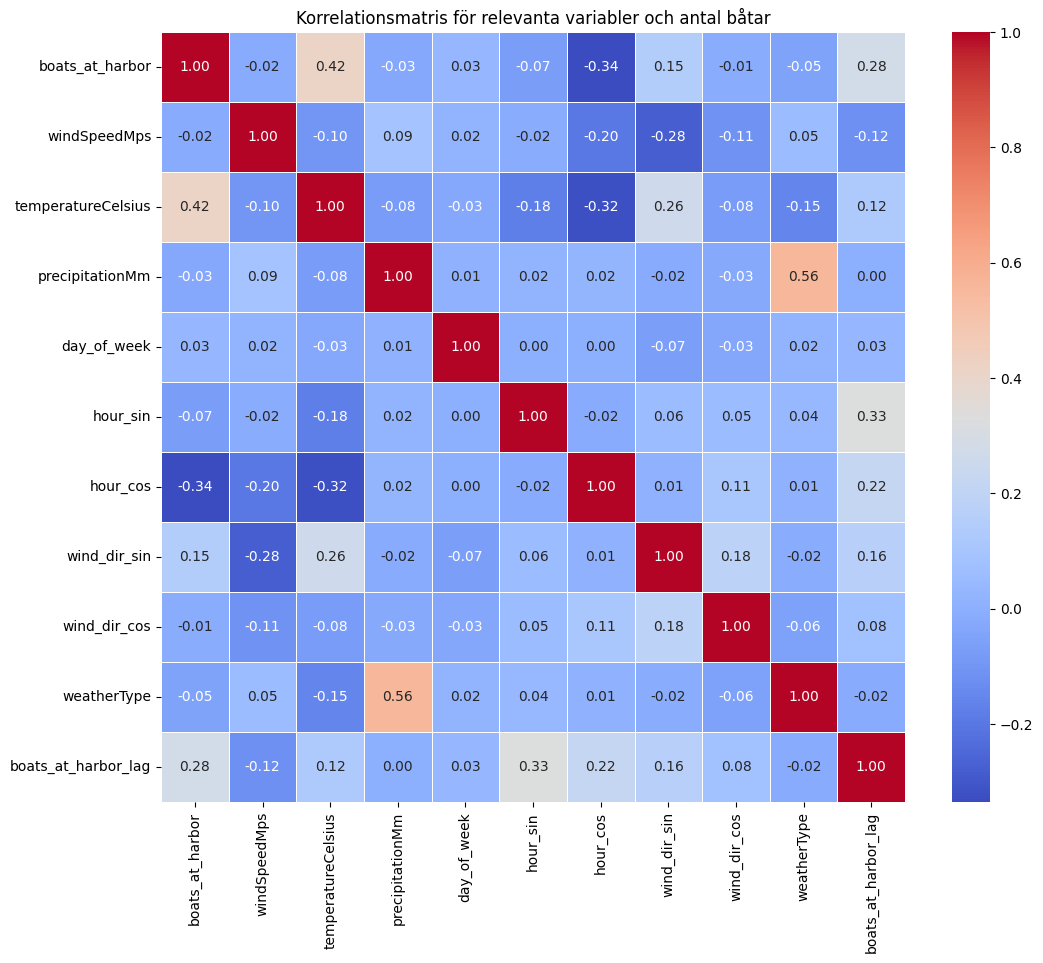

In [ ]:
top_harbor_ids = top_harbors.index

# Filtrera DataFrame för att endast inkludera data från de 10 största hamnarna
df_top_harbors = df[df['hamnId'].isin(top_harbor_ids)]

# Välj ut relevanta numeriska kolumner för korrelationsanalys
relevant_cols = [
    'boats_at_harbor',
    'windSpeedMps',
    'temperatureCelsius',
    'precipitationMm',
    'day_of_week',
    'hour_sin',
    'hour_cos',
    'wind_dir_sin',
    'wind_dir_cos',
    'weatherType',
    'boats_at_harbor_lag'
]

# Beräkna korrelationsmatrisen
correlation_matrix = df_top_harbors[relevant_cols].corr()

# Visualisera korrelationsmatrisen som en heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=.5
)
plt.title('Korrelationsmatris för relevanta variabler och antal båtar')
plt.show()

## Skapa regressionsmodell

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Välj ut relevanta funktioner och målvariabel
features = [
    'boats_at_harbor_lag',
    'windSpeedMps',
    'temperatureCelsius',
    'precipitationMm',
    'day_of_week',
    'hour_sin',
    'hour_cos',
    'wind_dir_sin',
    'wind_dir_cos',
    'weatherType'
]
target = 'boats_at_harbor'

X = df_top_harbors[features]
y = df_top_harbors[target]

# Dela upp data i tränings- och testset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Träningsset storlek: {len(X_train)} rader")
print(f"Testset storlek: {len(X_test)} rader")

Träningsset storlek: 83388 rader
Testset storlek: 20848 rader


### Träna den linjära regressionsmodellen

In [ ]:
# Initiera och träna modellen
model = LinearRegression()
model.fit(X_train, y_train)

print("Modellen har tränats klart: LinearRegression.")

Modellen har tränats klart: LinearRegression.


### Träna RandomForest modellen

In [ ]:
# Initiera och träna modellen
regressor = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    oob_score=True
)
regressor.fit(X_train, y_train)

print("Modellen har tränats klart: RandomForest.")

Modellen har tränats klart: RandomForest.


# Utvärdera RandomForest

In [ ]:
# Out-of-Bag Score: Measures how well the model
# generalizes on unseen samples, a low value indicates weaker generalization.
print("Out-of-Bag Score:", regressor.oob_score_)

y_pred_rf = regressor.predict(X_test)

mse_rf = mean_squared_error(y_test, y_pred_rf)
print("Mean Squared Error (RandomForest):", mse_rf)

r2_rf = r2_score(y_test, y_pred_rf)
print("R-squared (RandomForest):", r2_rf)

Out-of-Bag Score: 0.5553833410716328
Mean Squared Error (RandomForest): 10.85501086580155
R-squared (RandomForest): 0.546106133063355


# Utvärdera LinearRegression

In [ ]:
# Gör förutsägelser på testsetet
y_pred_lr = model.predict(X_test)

# Beräkna och skriv ut utvärderingsmått
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Mean Absolute Error (MAE) (LinearRegression): {mae_lr:.2f}")
print(f"Mean Squared Error (MSE) (LinearRegression): {mse_lr:.2f}")
print(f"Root Mean Squared Error (RMSE) (LinearRegression): {rmse_lr:.2f}")
print(f"R-squared (R²) (LinearRegression): {r2_lr:.2f}")

Mean Absolute Error (MAE) (LinearRegression): 2.71
Mean Squared Error (MSE) (LinearRegression): 16.27
Root Mean Squared Error (RMSE) (LinearRegression): 4.03
R-squared (R²) (LinearRegression): 0.32


In [ ]:
results = pd.DataFrame({'Actual': y_test, 'Predicted (LinearRegression)': y_pred_lr, 'Predicted (RandomForest)': y_pred_rf})
display(results.head(40))

,Actual,Predicted (LinearRegression),Predicted (RandomForest)
575814,22,7.364560,9.220000
852530,9,4.939985,5.410000
300077,10,6.271132,6.418333
45749,1,4.822946,2.737500
185920,1,6.218954,4.740000
677925,1,3.060719,2.310000
251585,3,2.078888,1.760000
138583,2,2.851508,2.080000
921018,1,1.132896,1.560000
335140,13,6.992362,6.639500
